## Bergman Minimal Model - BG Forecasting

In [1]:
!pip install -r ../requirements.txt

Using subject id: 540
Initial Gb (mean first 30min): 68.33, initial Ib (basal mean): 0.465
Initial params: [2.00000000e-02 3.00000000e-02 1.00000000e-03 6.83333333e+01
 4.65461528e-01]
Bounds lower: [1e-06, 1e-06, 0.0, 30.0, 0.0]
Bounds upper: [1.0, 1.0, 1.0, 400.0, np.float64(31.0)]

Fitting Bergman minimal model parameters using least squares (this may take a moment)...
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         6.4706e+07                                    3.29e+08    
       1              2         3.7825e+07      2.69e+07       3.17e+01       8.95e+09    
       2              8         3.7825e+07      0.00e+00       0.00e+00       8.95e+09    
`xtol` termination condition is satisfied.
Function evaluations 8, initial cost 6.4706e+07, final cost 3.7825e+07, first-order optimality 8.95e+09.

Optimization success: True | message: `xtol` termination condition is satisfied.
Fitted params:
 p1 (SG) = 0.147

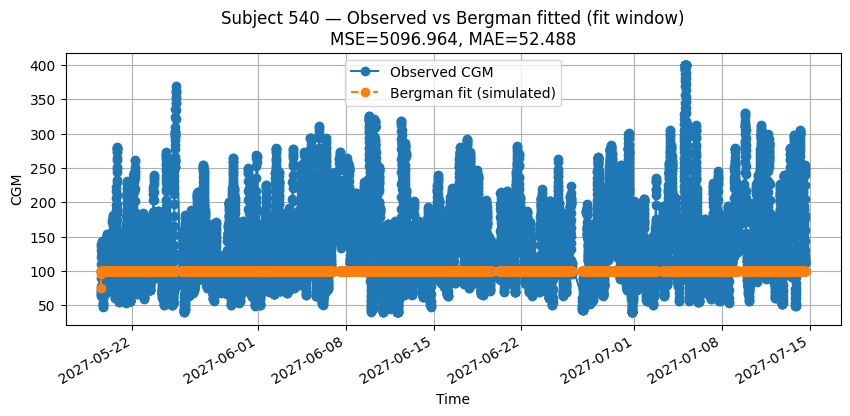


Forecast anchor index (global): 14841, time: 2027-07-14 15:30:00, G0=242.00


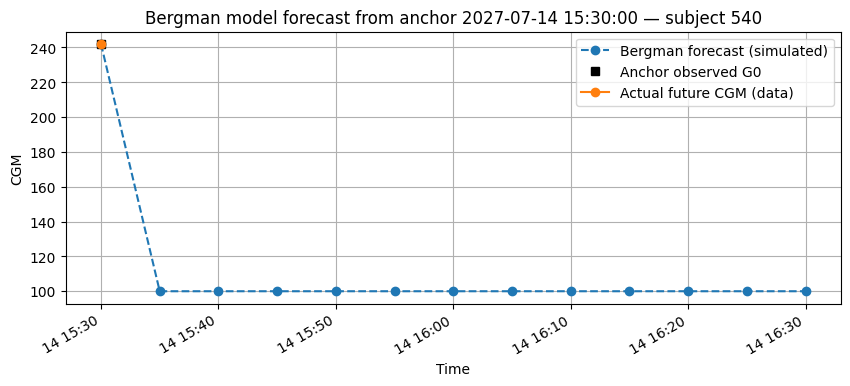


Done. Summary:
Fitted parameters: p1=0.147795, p2=0.017274, p3=0.07664863, Gb=100.01, Ib=0.052311
Fit-window MSE=5096.964, MAE=52.488
Notes: this is a simplified Bergman minimal model fit. Results are sensitive to insulin proxy, initial guesses, and window chosen.


In [2]:
# Bergman minimal model parameter estimation + forecasting (single cell)
# Paste into a Jupyter notebook cell and run.
# Requires: numpy, pandas, matplotlib, scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ------------------ Configuration ------------------
DATA_PATH = "../data/OhioT1DM.csv"
SUBJECT_ID = None      # None -> first subject in file; otherwise set e.g. '558' or integer depending on dataset
LOOKBACK_MIN = None    # if you want to fit on initial segment only (None -> use entire subject available)
FIT_START_IDX = 0      # starting index in subject time series for fit window
MAX_FIT_MIN = None     # if not None, only use this many minutes for fitting (useful to shorten)
FORECAST_MIN = 60      # minutes to forecast ahead from anchor
STEP_MIN = 5           # data sampling interval in minutes (assumed)
PLOT_EXAMPLE_IDX = None  # index within test portion for example plot (None -> middle)
# ---------------------------------------------------

# ------------------ Load data ----------------------
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df = df.sort_values(['id','date']).reset_index(drop=True)

# choose subject
if SUBJECT_ID is None:
    SUBJECT_ID = df['id'].unique()[0]
print("Using subject id:", SUBJECT_ID)
sub = df[df['id'] == SUBJECT_ID].sort_values('date').reset_index(drop=True)

# We need CGM and insulin proxies (basal+bolus). Drop rows missing CGM.
sub = sub.dropna(subset=['CGM']).reset_index(drop=True)
if sub.empty:
    raise RuntimeError("No CGM data for chosen subject.")

# Build insulin proxy: simple sum of basal + bolus.
# NOTE: bolus is typically given at a single time (delta). To make it smoother, we optionally spread bolus over a short window.
# We'll use a short rolling window (e.g., spread each bolus over 30 minutes) to approximate insulin action input shape.
spread_bolus_minutes = 30
spread_steps = max(1, spread_bolus_minutes // STEP_MIN)

basal = sub['basal'].fillna(0.0).values.astype(float)
bolus = sub['bolus'].fillna(0.0).values.astype(float)

# spread bolus as simple moving average (causal spreading)
bolus_spread = np.convolve(bolus, np.ones(spread_steps)/spread_steps, mode='full')[:len(bolus)]

I_proxy = basal + bolus_spread  # proxy insulin time series (units arbitrary, consistent within fit)

times = (sub['date'] - sub['date'].iloc[0]).dt.total_seconds().values / 60.0  # minutes since start
G_obs = sub['CGM'].values.astype(float)

# Optionally restrict fit window length
if MAX_FIT_MIN is not None:
    max_samples = int(np.floor(MAX_FIT_MIN / STEP_MIN))
    end_idx = min(len(times), FIT_START_IDX + max_samples)
else:
    end_idx = len(times)

t_fit = times[FIT_START_IDX:end_idx]
G_fit = G_obs[FIT_START_IDX:end_idx]
I_fit = I_proxy[FIT_START_IDX:end_idx]

if len(t_fit) < 10:
    raise RuntimeError("Not enough data points in fit window. Increase window or choose another subject.")

# baseline estimates (initial guesses)
Gb_init = np.mean(G_fit[:max(1, int(30/STEP_MIN))])  # baseline G from first 30 minutes
Ib_init = np.mean(basal)                             # baseline insulin from basal
print(f"Initial Gb (mean first 30min): {Gb_init:.2f}, initial Ib (basal mean): {Ib_init:.3f}")

# ------------------ Bergman model ODEs ------------------
def bergman_rhs(t, y, p1, p2, p3, Gb, Ib, t_vec, I_vec):
    # y = [G, X]
    # Interpolate I at time t (minutes)
    I_t = np.interp(t, t_vec, I_vec)
    G, X = y
    dGdt = - (p1 + X) * (G - Gb)
    dXdt = - p2 * X + p3 * (I_t - Ib)
    return [dGdt, dXdt]

def simulate_bergman(params, t_eval, I_t, G0=None, X0=0.0, t_vec=None):
    # params: [p1, p2, p3, Gb, Ib]
    p1, p2, p3, Gb, Ib = params
    if t_vec is None:
        t_vec = t_eval
    if G0 is None:
        # If no explicit G0, start from observed first value
        G0 = np.interp(t_eval[0], t_vec, I_t)  # placeholder (will be replaced by external G0 in practice)
    y0 = [G0, X0]
    sol = solve_ivp(bergman_rhs, (t_eval[0], t_eval[-1]), y0,
                    args=(p1, p2, p3, Gb, Ib, t_vec, I_t),
                    t_eval=t_eval, method='RK45', rtol=1e-5, atol=1e-6)
    if not sol.success:
        raise RuntimeError("ODE solver failed.")
    G_sim = sol.y[0]
    X_sim = sol.y[1]
    return G_sim, X_sim

# ------------------ residual function for least squares ------------------
def residuals_to_fit(params):
    # Unpack params
    p1, p2, p3, Gb, Ib = params
    # Simulate using initial glucose equal to first observed in fit window and X0=0
    G0 = float(G_fit[0])
    try:
        G_sim, X_sim = simulate_bergman(params, t_fit, I_fit, G0=G0, X0=0.0, t_vec=t_fit)
    except Exception as e:
        # Return large residuals to discourage optimizer from exploring this region
        print("Simulation failed for params:", params, "err:", e)
        return 1e6 * np.ones_like(G_fit)
    # residuals: simulated - observed
    res = G_sim - G_fit
    return res

# ------------------ initial guesses & bounds ------------------
# sensible initial guesses (these are heuristics; you may need to change them)
p1_init = 0.02   # glucose effectiveness [1/min] (typical order tiny)
p2_init = 0.03   # insulin action decay [1/min]
p3_init = 1e-3   # insulin sensitivity scaling (depends on insulin units chosen)
Gb_init = Gb_init
Ib_init = Ib_init

x0 = np.array([p1_init, p2_init, p3_init, Gb_init, Ib_init])

# bounds: p1,p2,p3 positive; Gb between 30 and 400; Ib non-negative
lower = [1e-6, 1e-6, 0.0, 30.0, 0.0]
upper = [1.0, 1.0, 1.0, 400.0, np.max(I_fit)*10 + 1.0]

print("Initial params:", x0)
print("Bounds lower:", lower)
print("Bounds upper:", upper)

# ------------------ Perform least-squares fit ------------------
print("\nFitting Bergman minimal model parameters using least squares (this may take a moment)...")
res_lsq = least_squares(residuals_to_fit, x0, bounds=(lower, upper),
                        verbose=2, xtol=1e-6, ftol=1e-6, max_nfev=200)

p_fit = res_lsq.x
print("\nOptimization success:", res_lsq.success, "| message:", res_lsq.message)
p1_fit, p2_fit, p3_fit, Gb_fit, Ib_fit = p_fit
print(f"Fitted params:\n p1 (SG) = {p1_fit:.6f} 1/min\n p2 = {p2_fit:.6f} 1/min\n p3 = {p3_fit:.8f}\n Gb = {Gb_fit:.2f}\n Ib = {Ib_fit:.6f}")

# ------------------ Simulate fitted model on fit window and compute metrics ------------------
G_sim_fit, X_sim_fit = simulate_bergman(p_fit, t_fit, I_fit, G0=float(G_fit[0]), X0=0.0, t_vec=t_fit)
mse_fit = mean_squared_error(G_fit, G_sim_fit)
mae_fit = mean_absolute_error(G_fit, G_sim_fit)
print(f"\nFit-window metrics: MSE={mse_fit:.3f}, MAE={mae_fit:.3f}")

# Plot observed vs fitted over the fit window
plt.figure(figsize=(10,4))
plt.plot(sub['date'].iloc[FIT_START_IDX:FIT_START_IDX + len(t_fit)], G_fit, 'o-', label='Observed CGM')
plt.plot(sub['date'].iloc[FIT_START_IDX:FIT_START_IDX + len(t_fit)], G_sim_fit, 'o--', label='Bergman fit (simulated)')
plt.xlabel("Time"); plt.ylabel("CGM")
plt.title(f"Subject {SUBJECT_ID} — Observed vs Bergman fitted (fit window)\nMSE={mse_fit:.3f}, MAE={mae_fit:.3f}")
plt.legend(); plt.grid(True)
plt.gcf().autofmt_xdate()
plt.show()

# ------------------ Forecasting from an anchor / initial point ------------------
# Choose anchor (index within subject) to start forecasting from. We'll let user pick or default to middle of series.
anchor_global_idx = FIT_START_IDX + len(t_fit) - 1  # default: last point of the fit window
# You can set anchor_global_idx to any index in subject's time series (0..len(sub)-1)
anchor_time = sub['date'].iloc[anchor_global_idx]
G0_anchor = sub['CGM'].iloc[anchor_global_idx]
print(f"\nForecast anchor index (global): {anchor_global_idx}, time: {anchor_time}, G0={G0_anchor:.2f}")

# Build forecast time vector (minutes) continuing from anchor
n_forecast_steps = int(np.ceil(FORECAST_MIN / STEP_MIN))
t_forecast_rel = np.arange(0, (n_forecast_steps + 1) * STEP_MIN, STEP_MIN)  # includes t=0 anchor
# absolute times (minutes since dataset start)
t_anchor_abs = (anchor_time - sub['date'].iloc[0]).total_seconds() / 60.0
t_forecast_abs = t_anchor_abs + t_forecast_rel

# build insulin proxy for forecasting: if we have future insulin measurements in the dataset, use them; otherwise assume basal continues
# find indices for times after anchor_global_idx to anchor_global_idx + n_forecast_steps
start_idx = anchor_global_idx
end_idx = min(len(sub) - 1, anchor_global_idx + n_forecast_steps)
I_future_available = False
if end_idx > start_idx:
    I_future = I_proxy[start_idx: end_idx + 1]  # includes anchor point
    # If fewer points than needed, extend with last basal value
    if len(I_future) < len(t_forecast_rel):
        last_basal = basal[-1] if len(basal)>0 else 0.0
        extend_len = len(t_forecast_rel) - len(I_future)
        I_future = np.concatenate([I_future, np.repeat(last_basal, extend_len)])
    I_future_available = True
else:
    # no future insulin samples available; use last basal
    last_basal = basal[-1] if len(basal)>0 else 0.0
    I_future = np.repeat(last_basal, len(t_forecast_rel))

# use full forecast absolute times as interpolation grid
# simulate with t_eval = t_forecast_rel added to anchor time (we must provide t_vec that covers I_future indexing)
# easiest: create t_vec that corresponds to I_future timestamps (minutes relative to start)
# Build t_vec for I_future: times at indices start_idx..start_idx+len(I_future)-1
t_vec_I = times[start_idx:start_idx + len(I_future)]
# But t_vec_I may be shorter/longer; to be safe create a grid aligned with t_forecast_abs
t_vec_for_sim = t_forecast_abs

# simulate from t_anchor_abs to t_anchor_abs + forecast horizon, but the solver expects times relative to dataset start
t_eval_sim = t_forecast_abs  # minutes since dataset start
# initial G0 and X0=last X_sim_fit[-1] if available else 0
X0_anchor = float(X_sim_fit[-1]) if 'X_sim_fit' in locals() else 0.0

G_forecast_sim, X_forecast_sim = simulate_bergman(p_fit, t_eval_sim, I_future, G0=G0_anchor, X0=X0_anchor, t_vec=t_vec_for_sim)

# Build arrays for plotting: convert t_eval_sim to datetime
t_datetimes = [sub['date'].iloc[0] + pd.Timedelta(minutes=float(tt)) for tt in t_eval_sim]

# actual CGM in future (if available in dataset)
actual_mask = (sub['date'] >= anchor_time) & (sub['date'] <= anchor_time + pd.Timedelta(minutes=FORECAST_MIN))
actual_future_times = sub.loc[actual_mask, 'date']
actual_future_cgm = sub.loc[actual_mask, 'CGM'].values

# Plot forecast
plt.figure(figsize=(10,4))
# plot anchor plus forecast
plt.plot(t_datetimes, G_forecast_sim, 'o--', label='Bergman forecast (simulated)')
# plot anchor observed point
plt.plot(anchor_time, G0_anchor, 'ks', label='Anchor observed G0')
# plot actual future if available
if len(actual_future_cgm) > 0:
    plt.plot(actual_future_times, actual_future_cgm, 'o-', label='Actual future CGM (data)')
plt.xlabel("Time"); plt.ylabel("CGM")
plt.title(f"Bergman model forecast from anchor {anchor_time} — subject {SUBJECT_ID}")
plt.legend(); plt.grid(True)
plt.gcf().autofmt_xdate()
plt.show()

# ------------------ End ------------------
print("\nDone. Summary:")
print(f"Fitted parameters: p1={p1_fit:.6f}, p2={p2_fit:.6f}, p3={p3_fit:.8f}, Gb={Gb_fit:.2f}, Ib={Ib_fit:.6f}")
print(f"Fit-window MSE={mse_fit:.3f}, MAE={mae_fit:.3f}")
print("Notes: this is a simplified Bergman minimal model fit. Results are sensitive to insulin proxy, initial guesses, and window chosen.")
